In [1]:
# source-cells: 0
from pathlib import Path
import sys
from io import BytesIO
import imageio.v3 as iio
from PIL import Image as PILImage
import numpy as np
import skimage as ski
import cv2
from matplotlib import pyplot as plt
from matplotlib.colors import NoNorm

BOOK = Path('book') if Path('book').is_dir() else Path('.')
sys.path.insert(0, str(BOOK.resolve()))
from _support import image_path, show_images, lab, diagram

plt.rcParams['image.cmap'] = 'gray'

def rgb_decomposition(image, channel):
    weights = np.ones(3, dtype=np.float32)
    weights[{'r': 0, 'g': 1, 'b': 2}[channel.lower()]] = 0
    return np.asarray(image) * weights

def imshow_all(*images, titles=None, **kwargs):
    return show_images(*images, titles=titles, **kwargs)

def imshow_with_histogram(image):
    fig, (ax_image, ax_hist) = plt.subplots(1, 2, figsize=(12, 4))
    ax_image.imshow(image)
    for channel, color, label in zip(np.moveaxis(image, -1, 0), 'rgb', ['L', 'a', 'b']):
        counts, centers = ski.exposure.histogram(channel)
        ax_hist.fill_between(centers, counts, alpha=0.3, color=color, label=label)
    ax_image.set_title('LAB interpreted as RGB: incorrect colors')
    ax_hist.set_xlabel('channel value')
    ax_hist.set_ylabel('pixel count')
    ax_hist.legend()
    fig.tight_layout()
    plt.show()

def plot_img_and_hist(image, axes, bins=256):
    image = ski.util.img_as_float(image)
    ax_img, ax_hist = axes
    ax_cdf = ax_hist.twinx()
    ax_img.imshow(image, cmap='gray', vmin=0, vmax=1)
    ax_img.set_axis_off()
    ax_hist.hist(image.ravel(), bins=bins, histtype='step', color='black')
    ax_hist.ticklabel_format(axis='y', style='scientific', scilimits=(0, 0))
    ax_hist.set_xlabel('Pixel intensity')
    ax_hist.set_xlim(0, 1)
    ax_hist.set_yticks([])
    img_cdf, centers = ski.exposure.cumulative_distribution(image, bins)
    ax_cdf.plot(centers, img_cdf, 'r')
    ax_cdf.set_yticks([])
    return ax_img, ax_hist, ax_cdf

In [2]:
# source-cells: 1

# 影像處理基礎：從像素、色彩到幾何變換

先把影像看成可以讀取、計算與修改的陣列，再來理解色彩、曝光與幾何變換。本章保留同一組圖片在不同操作下的結果，讓每個參數的影響容易比較。

## 什麼是電腦視覺？

In [3]:
# source-cells: 2

電腦視覺研究如何從影像或影片取得物件、位置、形狀與動作等資訊。例如辨認照片中的文字，需要先讀取像素、校正拍攝角度，再判斷文字內容。影像處理提供讀寫、濾波與變換工具；幾何、物理與統計模型則幫助我們把像素連到要回答的問題。

In [4]:
# source-cells: 3

## 影像表示法

In [5]:
# source-cells: 4

點陣影像透過**取樣**與**量化**表示連續場景。取樣決定在空間哪些位置記錄資料，量化則把強度轉成有限個數值。每個樣本稱為像素；影像寬、高描述取樣格點數，bit depth 描述每個通道可表示的數值層級。取樣密度、可分辨的細節與位元深度是不同概念。

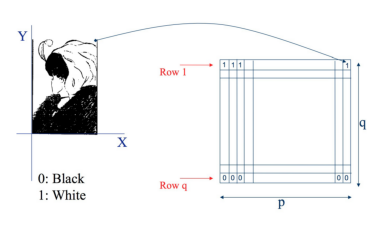

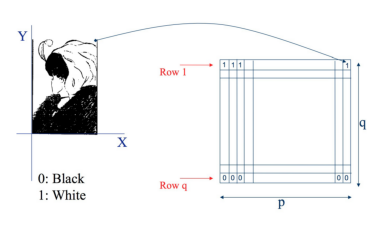

In [6]:
# source-cells: 4
# 原教學示意圖 1；來源：https://drive.google.com/uc?id=16zc4EH8oi7RtJboZGC8Cw1mWVikKGwZB
show_images(ski.io.imread(image_path('ch01-cell4-1.png')))

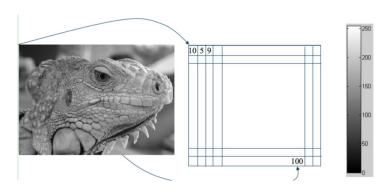

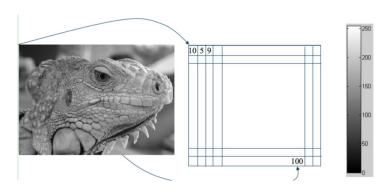

In [7]:
# source-cells: 5
# 原教學示意圖 1；來源：https://drive.google.com/uc?id=170NOZD-HtG4jt-PBKwmY_oM8-acr3a92
show_images(ski.io.imread(image_path('ch01-cell5-1.png')))

In [8]:
# source-cells: 6

把影像放大到像素尺度，可以看到格點中的數值如何排列。[PixSpy](https://pixspy.com/) 可直接讀取圖片的像素、色彩與座標，適合拿自己的圖片試看。

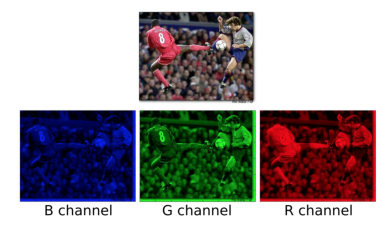

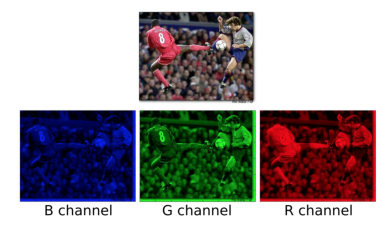

In [9]:
# source-cells: 6
# 原教學示意圖 1；來源：https://drive.google.com/uc?id=170igILkg6b76ofZv1eOddgUuH7-wYpit
show_images(ski.io.imread(image_path('ch01-cell6-1.png')))

In [10]:
# source-cells: 7

## 影像是 NumPy 陣列

In [11]:
# source-cells: 8

`scikit-image` 直接以 NumPy 陣列處理影像。常用的搭配還有 [SciPy ndimage](https://docs.scipy.org/doc/scipy/reference/ndimage.html#module-scipy.ndimage) 的多維濾波與形態學、[Pillow](https://pillow.readthedocs.io/en/stable/handbook/index.html) 的圖片讀寫，以及 [Mahotas](https://luispedro.org/software/mahotas/) 的影像分析。

In [12]:
# source-cells: 9

需要其他影像功能時，也可使用 [OpenCV](https://docs.opencv.org/4.x/d6/d00/tutorial_py_root.html)、[SimpleITK](https://github.com/InsightSoftwareConsortium/SimpleITK-Notebooks/blob/master/Python/01_Image_Basics.ipynb) 或 [pycairo](https://github.com/pygobject/pycairo)。前兩者提供影像分析與變換，pycairo 則適合二維繪圖。

In [13]:
# source-cells: 10

共用 NumPy 陣列後，讀圖、數值運算與 Matplotlib 顯示可以接在一起。需要查某項功能在哪個子模組時，可使用 [scikit-image API 索引](https://scikit-image.org/docs/stable/api/api.html)。

In [14]:
# source-cells: 11

| 影像概念 | NumPy 表示 |
|---|---|
| 影像 | `np.ndarray` |
| 像素值 | `a[row, column]` |
| 通道 | 陣列的一個軸 |
| 數值儲存型別 | `dtype`，例如 `np.uint8`、`np.uint16`、`np.float64` |
| 濾波或變換 | 以陣列為輸入、輸出的函式 |

`dtype` 描述數值儲存方式；PNG、JPEG 等則是檔案編碼格式。

In [15]:
# source-cells: 12

先建立一張 $512\times512$ 的隨機灰階影像。每個值在 0 到 1 之間，顏色條顯示數值與亮度的對應。

In [16]:
# source-cells: 13
# shape 必須在建立陣列之後查詢；與下一格合併。

(512, 512)


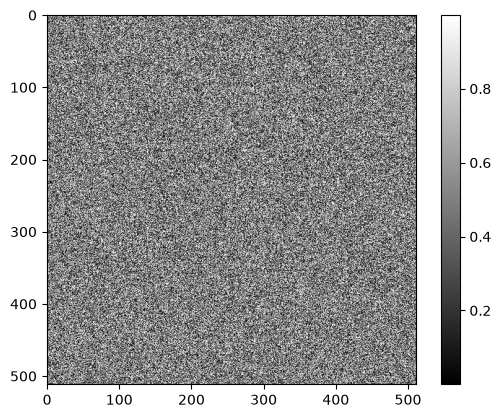

In [17]:
# source-cells: 14
random_image = np.random.random([512, 512])
print(random_image.shape)
plt.imshow(random_image, cmap='gray')
plt.colorbar();

In [18]:
# source-cells: 15

`skimage.data` 提供內建範例影像。先看硬幣圖的物件型別、元素型別與陣列形狀，再觀察圖中的亮度。

Type: <class 'numpy.ndarray'>
dtype: uint8
shape: (303, 384)


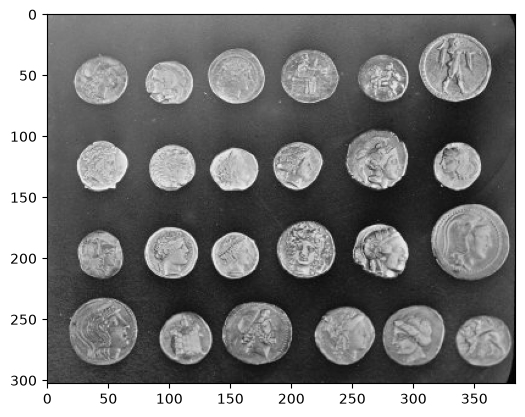

In [19]:
# source-cells: 16
coins = ski.data.coins()

print('Type:', type(coins))
print('dtype:', coins.dtype)
print('shape:', coins.shape)

plt.imshow(coins, cmap='gray');

In [20]:
# source-cells: 17

自己的圖片可用 `ski.io.imread()` 讀成陣列。以下使用原始的 Venusaur 灰階圖片；`image_path()` 指向已備妥的本地圖片。

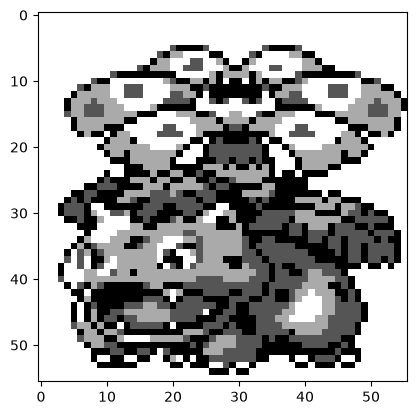

In [21]:
# source-cells: 18
venusaur = ski.io.imread(image_path('venusaur.png')).copy()
plt.imshow(venusaur, cmap='gray');

In [22]:
# source-cells: 19

`shape` 給出各軸長度，`size` 是陣列元素總數，`dtype` 則是每個元素的型別。

In [23]:
# source-cells: 20
venusaur.shape, venusaur.size, venusaur.dtype

((56, 56), 3136, dtype('uint8'))

In [24]:
# source-cells: 21

`min()`、`max()` 與 `mean()` 分別給出最低強度、最高強度與平均強度。這些摘要不包含像素的位置。

In [25]:
# source-cells: 22
venusaur.min(), venusaur.max(), venusaur.mean()

(np.uint8(0), np.uint8(255), np.float64(155.9327168367347))

In [26]:
# source-cells: 23

### 索引、座標與局部修改

In [27]:
# source-cells: 24

索引從 0 開始。`venusaur[11, 21]` 讀取第 12 列、第 22 欄；下面也會把索引 `[4, 11]` 的像素設成黑色。

In [28]:
# source-cells: 25
# 索引從 0 起算：第 12 列、第 22 欄
venusaur[11, 21]

np.uint8(170)

In [29]:
# source-cells: 26
# 索引 [4,11] 的像素設為黑色
venusaur[4, 11] = 0

In [30]:
# source-cells: 27

灰階陣列的第一軸是列（row），第二軸是欄（column）。`[0, 0]` 位於左上角，列索引向下增加、欄索引向右增加。

In [31]:
# source-cells: 28

若改用平面座標，通常寫成 `(x=column, y=row)`。Matplotlib 的 `imshow()` 預設 `origin="upper"`，同樣把原點放在左上；一般曲線圖常採向上的 y 軸，兩種顯示慣例需要分清。

In [32]:
# source-cells: 29

常見的灰階顯示尺度有 0–255 與 0–1。前者常搭配 `uint8`，後者常搭配浮點數。數值範圍本身仍需配合檔案與函式的定義解讀。

In [33]:
# source-cells: 30
## Slicing: Set the first ten lines to "black" (0)
venusaur[:10] = 0

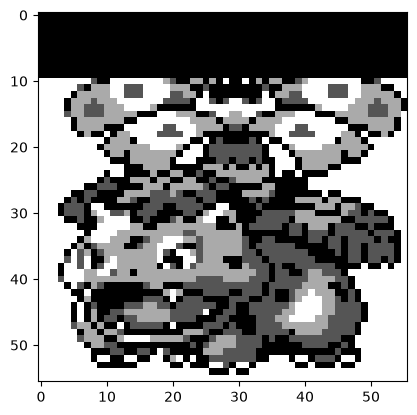

In [34]:
# source-cells: 31
plt.imshow(venusaur, cmap='gray');

In [35]:
# source-cells: 32

布林遮罩可以選出不規則區域。對二維影像做布林索引時，遮罩必須匹配被索引的維度；遮罩本身可用 `ogrid` 的廣播運算建立。這裡沿用 `mgrid`，把中心圓盤外的像素設為零。

In [36]:
# source-cells: 33
# mgrid 在下一格先取得 nrows、ncols 後建立。

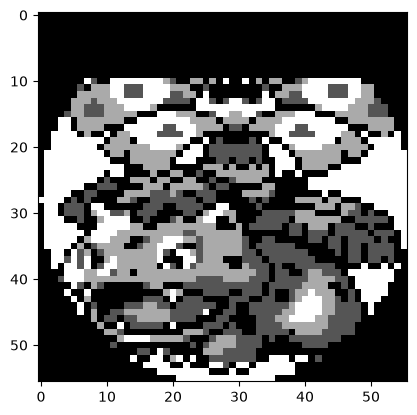

In [37]:
# source-cells: 34
nrows, ncols = venusaur.shape
row, col = np.mgrid[0:nrows, 0:ncols] # You can also use ogrid and use broadcasting to save memory
cnt_row, cnt_col = nrows / 2, ncols / 2
outer_disk_mask = ((row - cnt_row)**2 + (col - cnt_col)**2 > (nrows / 2)**2)
venusaur[outer_disk_mask] = 0
plt.imshow(venusaur, cmap='gray');

In [38]:
# source-cells: 35

## 影像資料型別與數值範圍

原教學延伸連結：[相關說明](https://scikit-image.org/docs/stable/user_guide/data_types.html)。可對照本節的定義與參數閱讀。

In [39]:
# source-cells: 36

在 `skimage` 中，影像就是一般的 `NumPy` 陣列，而 `NumPy` 支援多種資料型別（即 "dtypes"）。為了避免扭曲影像強度，`skimage` 假設影像遵循以下的資料型別與數值範圍：

| 資料型別   | 數值範圍                         |
| ------ | ---------------------------- |
| uint8  | 0 到 255                      |
| uint16 | 0 到 65535                    |
| uint32 | 0 到 $2^{32} - 1$           |
| float  | -1 到 1 或 0 到 1               |
| int8   | -128 到 127                   |
| int16  | -32768 到 32767               |
| int32  | $-2^{31}$ 到 $2^{31} - 1$ |

In [40]:
# source-cells: 37

上表的整數範圍由 dtype 決定，浮點範圍則是 scikit-image 常用的影像慣例，並非浮點型別的儲存限制。浮點陣列可以超出此範圍，是否可輸入某個函式要查該函式的要求。

`astype(float)` 只換型別、保留數字；`img_as_float()` 對整數會依型別範圍重新縮放。兩者適合的情境不同。下面把同一組 `uint8` 數字分別轉換，就能看出差異。

In [41]:
# source-cells: 38
image = np.arange(0, 50, 10, dtype=np.uint8)
print(image.astype(float))  # 保留 0,10,20,30,40
print(ski.util.img_as_float(image))  # 依 uint8 範圍除以 255

[ 0. 10. 20. 30. 40.]
[0.         0.03921569 0.07843137 0.11764706 0.15686275]


In [42]:
# source-cells: 39

### 輸入型別與轉換工具

In [43]:
# source-cells: 40

| 函式 | 轉換結果 |
|---|---|
| `img_as_float()` | 浮點影像；整數輸入會縮放，浮點輸入保留原數值 |
| `img_as_ubyte()` | 8 位元無號整數 `uint8` |
| `img_as_uint()` | 16 位元無號整數 `uint16` |
| `img_as_int()` | 16 位元有號整數 `int16` |

這些函式會依影像型別慣例調整數值。以下把 0、0.5、1 換成 `uint8`。

In [44]:
# source-cells: 41
# These functions convert images to the desired dtype and properly rescale their values:

image = np.array([0, 0.5, 1], dtype=float)
ski.util.img_as_ubyte(image)

array([  0, 128, 255], dtype=uint8)

In [45]:
# source-cells: 42

`preserve_range=True` 讓幾何變換保留輸入數值的尺度。例如數字若表示溫度，就不宜自動除以整數型別最大值。下面把同一張硬幣圖縮小一半，比較預設轉換與保留範圍的輸出。

`img_as_float()` 不會將浮點輸入的最小、最大值自動拉成 0、1；保留精度的行為也和單純指定 `float64` 不同。

In [46]:
# source-cells: 43
coin = ski.data.coins()
coin.dtype, coin.min(), coin.max(), coin.shape

(dtype('uint8'), np.uint8(1), np.uint8(252), (303, 384))

In [47]:
# source-cells: 44
rescaled = ski.transform.rescale(coin, 0.5)
rescaled.dtype, np.round(rescaled.min(), 4), np.round(rescaled.max(), 4), rescaled.shape

(dtype('float64'), np.float64(0.0189), np.float64(0.9156), (152, 192))

In [48]:
# source-cells: 45
rescaled = ski.transform.rescale(coin, 0.5, preserve_range=True)
rescaled.dtype, np.round(rescaled.min()), np.round(rescaled.max()), rescaled.shape

(dtype('float64'), np.float64(5.0), np.float64(233.0), (152, 192))

In [49]:
# source-cells: 46

浮點數適合後續濾波與內插，因為結果通常不再是整數。轉換前仍要確認是否需要保留原始量尺。

In [50]:
# source-cells: 47

### 輸出型別

In [51]:
# source-cells: 48

輸出型別由各函式決定。下例先對硬幣圖計算 Sobel 邊緣強度，再轉成 `uint16`。色彩映射只負責呈現結果，和資料型別分開設定。

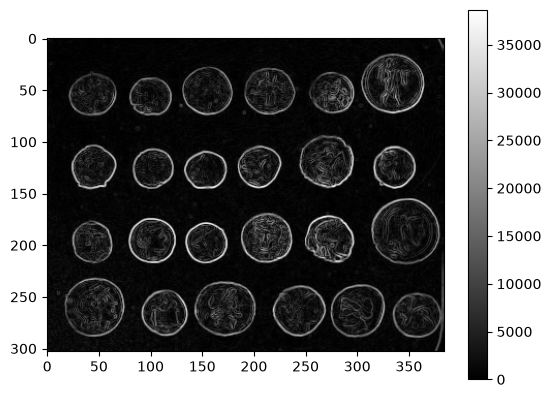

In [52]:
# source-cells: 49
out = ski.util.img_as_uint(ski.filters.sobel(coin))
plt.imshow(out)
plt.colorbar();

In [53]:
# source-cells: 50

## 影像輸入與輸出

原教學延伸連結：[相關說明](https://scikit-image.org/docs/stable/api/skimage.io.html)。可對照本節的定義與參數閱讀。

In [54]:
# source-cells: 51

讀寫程式把 PNG、JPEG 等檔案轉成陣列，或把陣列編碼成檔案。`ski.io.imread()` 與 `ski.io.imsave()` 提供直接介面；也可用 Pillow 或 imageio。實際支援的型別與通道取決於格式，例如 JPEG 不保留 alpha。

In [55]:
# source-cells: 52
# 舊 plugin 清單移至後端說明；目前使用 ski.io.imread。

In [56]:
# source-cells: 53
# 舊 plugin_info 移至後端說明。

In [57]:
# source-cells: 54
# 舊 loaded plugin 清單移至後端說明。

In [58]:
# source-cells: 55
# 不設定全域 plugin，使用目前讀寫後端。

In [59]:
# source-cells: 56
coins = ski.data.coins()
coins

array([[ 47, 123, 133, ...,  14,   3,  12],
       [ 93, 144, 145, ...,  12,   7,   7],
       [126, 147, 143, ...,   2,  13,   3],
       ...,
       [ 81,  79,  74, ...,   6,   4,   7],
       [ 88,  82,  74, ...,   5,   7,   8],
       [ 91,  79,  68, ...,   4,  10,   7]], shape=(303, 384), dtype=uint8)

In [60]:
# source-cells: 57

```{dropdown} 讀寫後端與舊版 plugin 介面
原教學使用 `find_available_plugins()`、`plugin_info()` 與 `use_plugin()` 比較讀寫後端。這些介面已淘汰，本章改用目前的讀寫函式，不要求安裝舊的 `imread` plugin。PNG 的無損讀回與 JPEG 編碼在下方以原 Venusaur 圖展示。
```

In [61]:
# source-cells: 58

## 色彩、通道與透明度

原教學延伸連結：[相關說明](https://scikit-image.org/docs/stable/api/skimage.color.html)。可對照本節的定義與參數閱讀。

In [62]:
# source-cells: 59

RGB 影像的 shape 通常是 `(row, column, 3)`，RGBA 則是 `(row, column, 4)`。alpha 是最後一軸的第四個通道，陣列仍是三維。PNG 可以是灰階、RGB 或 RGBA，通道數需由讀入後的 shape 確認。

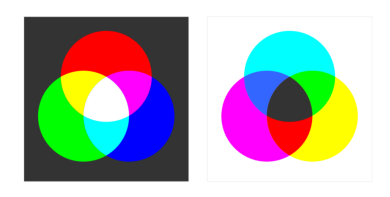

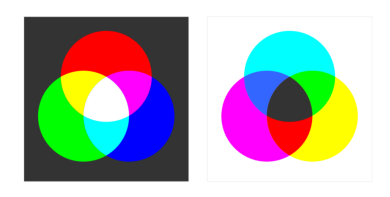

In [63]:
# source-cells: 59
# 原教學示意圖 1；來源：https://drive.google.com/uc?id=171RCIjgsQYhQTRv_xbUaviNi59staKjE
show_images(ski.io.imread(image_path('ch01-cell59-1.png')))

In [64]:
# source-cells: 60
# 這張 PNG 使用調色盤與透明索引；明確解碼為 RGBA，保留透明資訊。
with PILImage.open(image_path('venusaur-f.png')) as decoded:
    venusaurf = np.asarray(decoded.convert('RGBA')).copy()
venusaurf.shape

(80, 80, 4)

In [65]:
# source-cells: 61
# 不再切換已淘汰的 imread plugin。

Shape: (80, 80, 4)
Values min/max: 0 255


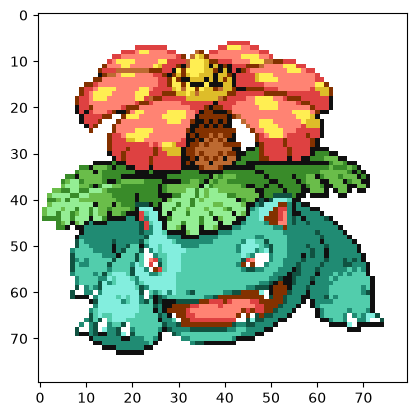

In [66]:
# source-cells: 62
print('Shape:', venusaurf.shape)
print('Values min/max:', venusaurf.min(), venusaurf.max())
plt.imshow(venusaurf);

In [67]:
# source-cells: 63
# JPEG 無 alpha：沿用原例取出前三通道，編碼到記憶體，避免覆寫來源圖。
# 另先用 PNG 做無損 round-trip，對照 JPEG 的有損編碼。
png_bytes = iio.imwrite("<bytes>", venusaurf, extension=".png")
assert np.array_equal(iio.imread(png_bytes, extension=".png"), venusaurf)
jpeg_buffer = BytesIO()
iio.imwrite(jpeg_buffer, venusaurf[:, :, :3], extension='.jpg')
jpeg_buffer.seek(0)
venusaur_jpeg = ski.io.imread(jpeg_buffer)
print('JPEG:', venusaur_jpeg.shape, venusaur_jpeg.dtype)
print('JPEG 與原 RGB 完全相同:', np.array_equal(venusaur_jpeg, venusaurf[:, :, :3]))

JPEG: (80, 80, 3) uint8
JPEG 與原 RGB 完全相同: False


In [68]:
# source-cells: 64

彩色像素一次回傳整組通道。下面先讀取兩個位置，再把 `[40, 75]` 改為不透明黑色、`[40, 76]` 改為不透明綠色。後面的通道與幾何例子沿用這張修改後的圖。

In [69]:
# source-cells: 65
venusaurf[10, 20], venusaurf[40, 75]

(array([255, 238,  82, 255], dtype=uint8), array([0, 0, 0, 0], dtype=uint8))

In [70]:
# source-cells: 66

此圖以 `uint8` 儲存 alpha：0 完全透明，255 完全不透明。RGB 三個值相同但 alpha 不同時，顯示結果也會不同。

In [71]:
# source-cells: 67
# 不透明黑色
venusaurf[40, 75] = [0, 0, 0, 255]

In [72]:
# source-cells: 68
# 不透明綠色
venusaurf[40, 76] = [0, 255, 0, 255]

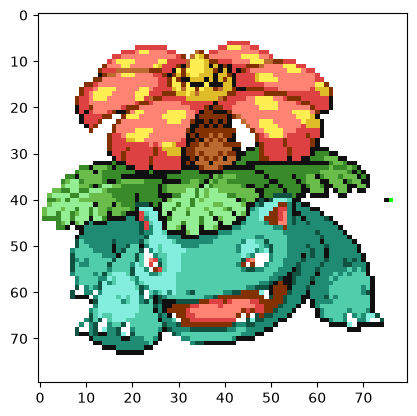

In [73]:
# source-cells: 69
plt.imshow(venusaurf);

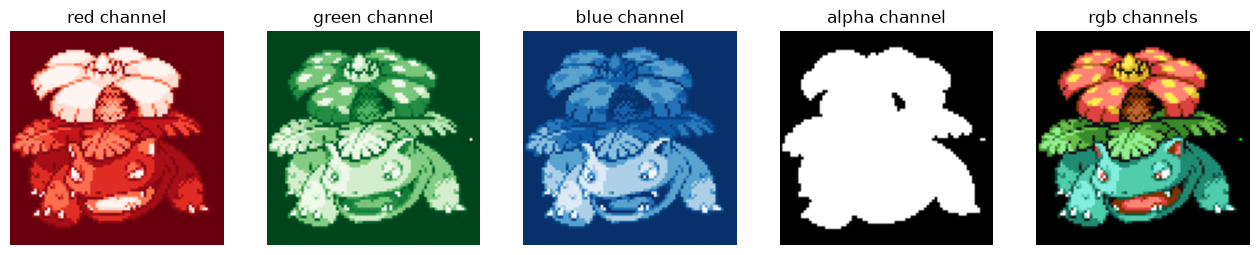

In [74]:
# source-cells: 70
# https://stackoverflow.com/questions/52632718/display-image-only-in-rred-channel-using-python (2D vs 3D)
r = venusaurf[:,:, 0]
g = venusaurf[:,:, 1]
b = venusaurf[:,:, 2]
a = venusaurf[:,:, 3]
# --- display the image and r, g, b channels ---
f, axes = plt.subplots(1, 5, figsize=(16, 5))
for ax in axes:
    ax.axis('off')
(ax_r, ax_g, ax_b, ax_a, ax_color) = axes
ax_r.imshow(r, cmap='Reds_r')
ax_r.set_title('red channel')
ax_g.imshow(g, cmap='Greens_r')
ax_g.set_title('green channel')
ax_b.imshow(b, cmap='Blues_r')
ax_b.set_title('blue channel')
ax_a.imshow(a, cmap='gray')
ax_a.set_title('alpha channel')
# --- Here, we stack the R, G, and B layers again to form a color image ---
venusaurf2 = np.stack([r, g, b], axis=2)
ax_color.imshow(venusaurf2)
ax_color.set_title('rgb channels');

In [75]:
# source-cells: 71
without_red = rgb_decomposition(venusaurf2, 'R')
without_green = rgb_decomposition(venusaurf2, 'G')
without_blue = rgb_decomposition(venusaurf2, 'B')

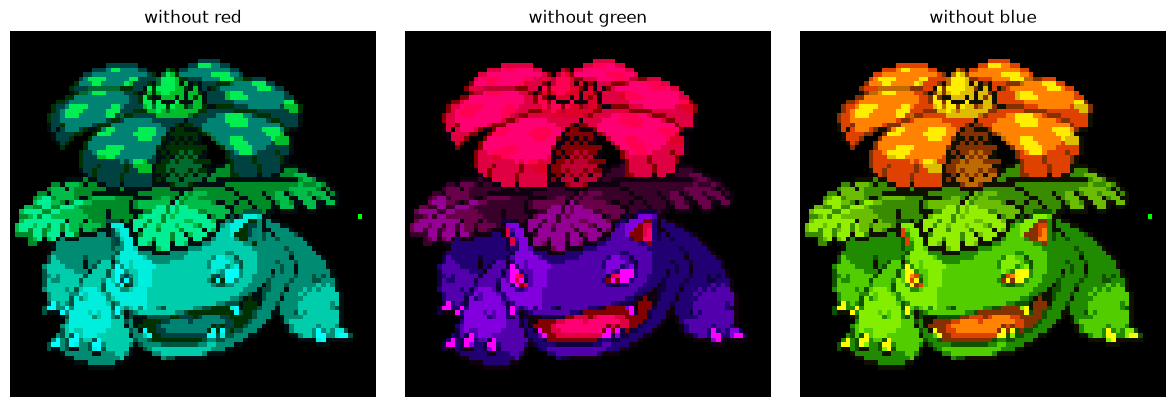

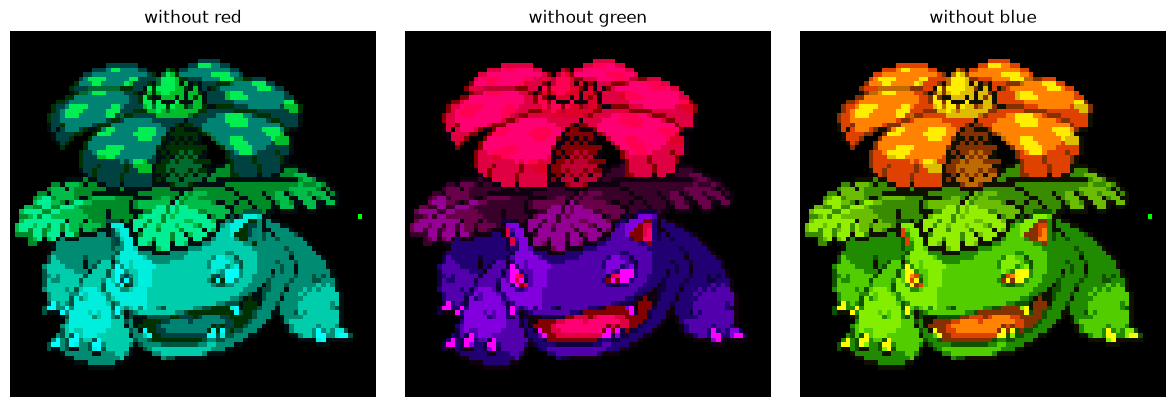

In [76]:
# source-cells: 72
# RGB 浮點顯示範圍：https://stackoverflow.com/questions/49643907/clipping-input-data-to-the-valid-range-for-imshow-with-rgb-data-0-1-for-floa
show_images(without_red / 255.0, without_green / 255.0, without_blue / 255.0,
            titles=['without red', 'without green', 'without blue'])

In [77]:
# source-cells: 73

下面的四張二維圖分別顯示 R、G、B、alpha 的數值；第五張把 RGB 重新堆疊，故意不使用 alpha。去掉紅、綠或藍通道，則能看出各通道對原顏色的貢獻。

In [78]:
# source-cells: 74

許多支援多通道的函式提供 `channel_axis`。最後一軸是通道時使用 `channel_axis=-1`；`None` 表示所有軸都視為空間軸。各函式的預設值不同，要依文件指定。

In [79]:
# source-cells: 75

| 影像類型 | 座標格式 |
|---|---|
| 2D 灰階 | `(row, column)` |
| 2D 多通道 | `(row, column, channel)` |
| 3D 灰階體積 | `(plane, row, column)` |
| 3D 多通道體積 | `(plane, row, column, channel)` |

影片也可能把時間放在第一軸；軸的物理意義要由資料來源決定。

In [80]:
# source-cells: 76

````{dropdown} 三維與逐平面處理
多維函式可一次處理體積，或沿第一軸逐片處理。以下只列讀法，避免為示意建立大型陣列；分割方法在下一章再介紹。

```python
from scipy import ndimage as ndi
# im3d 已是 (plane, row, column) 陣列
seeds = ndi.label(im3d < 0.1)[0]
ws = ski.segmentation.watershed(im3d, seeds)
edges = np.empty_like(im3d)
for pln, image in enumerate(im3d):
    edges[pln] = ski.filters.sobel(image)
```

`watershed` 位於 `ski.segmentation`。逐片 Sobel 保留片內邊緣，沒有計算片間方向的導數。
````

In [81]:
# source-cells: 77

### RGBA 轉成 RGB：和背景混合

In [82]:
# source-cells: 78

`rgba2rgb()` 預設把透明部分與白背景混合。先把通道轉成 0–1 的浮點尺度，再逐像素計算

$$\mathrm{rgb}_{out}=\alpha\,\mathrm{rgb}_{in}+(1-\alpha)\,\mathrm{background}.$$

直接丟棄 alpha 與和白背景混合會得到不同結果。

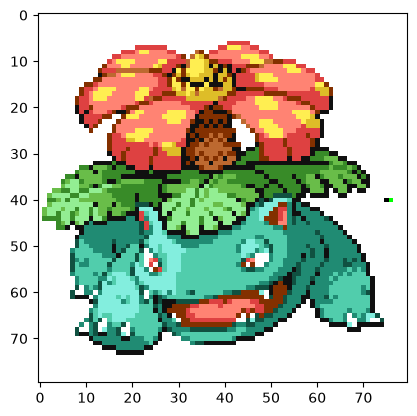

In [83]:
# source-cells: 79
img_rgb = ski.color.rgba2rgb(venusaurf)
plt.imshow(img_rgb);

In [84]:
# source-cells: 80
img_rgb.shape

(80, 80, 3)

In [85]:
# source-cells: 81

### 彩色與灰階之間的轉換

In [86]:
# source-cells: 82

[skimage.color](https://scikit-image.org/docs/stable/api/skimage.color.html#module-skimage.color) 提供 RGB、HSV、CIELAB 等轉換。RGB 到灰階會合併通道，因此無法從灰階唯一還原原本顏色。

In [87]:
# source-cells: 83

常見的線性 RGB 相對亮度權重為

$$Y=0.2126R+0.7152G+0.0722B.$$

下面保留這組權重與 `rgb2gray()` 的並排比較。scikit-image 使用 0.2125、0.7154、0.0721；此外，手算直接使用 `uint8` 的 0–255 值，套件則先換到 0–1，因此兩張圖各自顯示時看起來相近，數值量尺卻不同。若要比較數字，應先把手算結果除以 255。嚴格的相對亮度公式作用於線性 RGB；一般 sRGB 圖片還有非線性編碼，這裡示範的是通道加權。

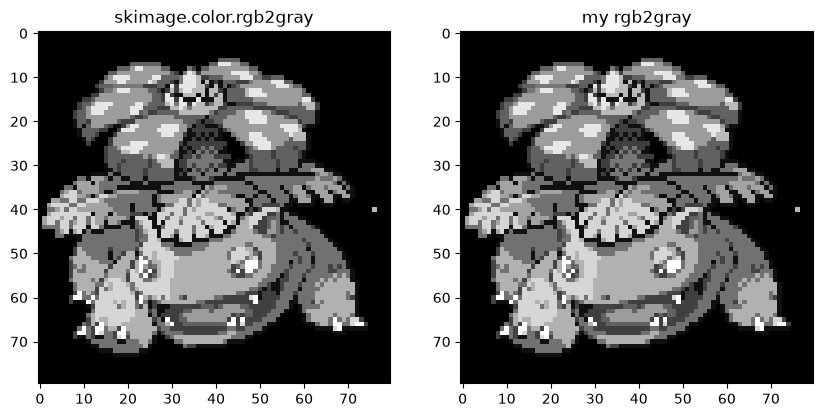

In [88]:
# source-cells: 84
# https://en.wikipedia.org/wiki/Grayscale#Converting_color_to_grayscale
gray = ski.color.rgb2gray(venusaurf2)
my_gray = venusaurf2 @ [0.2126, 0.7152, 0.0722]
# --- display the results ---
f, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 6))
ax0.imshow(gray, cmap='gray')
ax0.set_title('skimage.color.rgb2gray')
ax1.imshow(my_gray, cmap='gray')
ax1.set_title('my rgb2gray');

In [89]:
# source-cells: 85

`gray2rgb()` 只是把灰階複製到三個通道，得到的仍是沒有色彩差異的圖。

In [90]:
# source-cells: 86

### HSV 與 CIELAB

In [91]:
# source-cells: 87

HSV 將色彩描述為色相、飽和度與明度。三個座標有不同用途，並不表示它們在統計上互相獨立。飽和度為零時色相沒有唯一意義。以下先把一個飽和紅色像素轉成 HSV。CMYK 則常用於印刷，和這裡的顯示用 RGB 有不同用途。

In [92]:
# source-cells: 88
# bright saturated red
red_pixel_rgb = np.array([[[255, 0, 0]]], dtype=np.uint8)
ski.color.rgb2hsv(red_pixel_rgb)

array([[[0., 1., 1.]]])

In [93]:
# source-cells: 89

接著用 CIELAB 選出 Chelsea 貓圖中的眼睛與鼻子。先顯示亮度 `L*`、綠到紅的 `a*`，以及藍到黃的 `b*`，查看哪些通道能區分想要的區域。

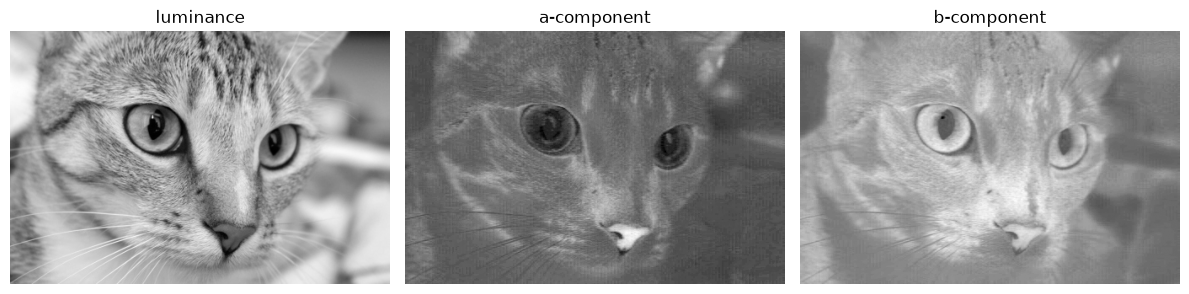

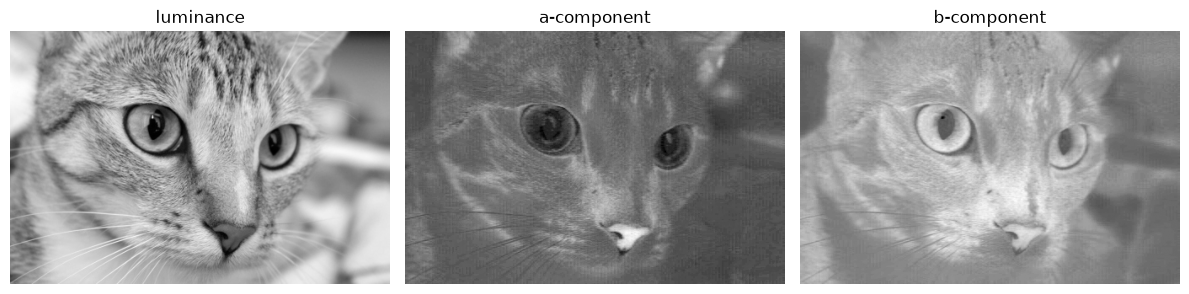

In [94]:
# source-cells: 90
color_image = ski.util.img_as_float(ski.data.chelsea())
lab_image = ski.color.rgb2lab(color_image)
luminance, a, b = np.rollaxis(lab_image, axis=-1)
titles = ['luminance', 'a-component', 'b-component']
imshow_all(luminance, a, b, titles=titles)

In [95]:
# source-cells: 91

`L*` 描述亮度，0 對應黑、100 對應參考白；`a*` 負值偏綠、正值偏紅，`b*` 負值偏藍、正值偏黃。原圖的眼睛在 `a*` 圖上較暗，鼻子則較亮，可利用不同閾值選取。先回看原彩色圖，再用直方圖查看通道值的分布。

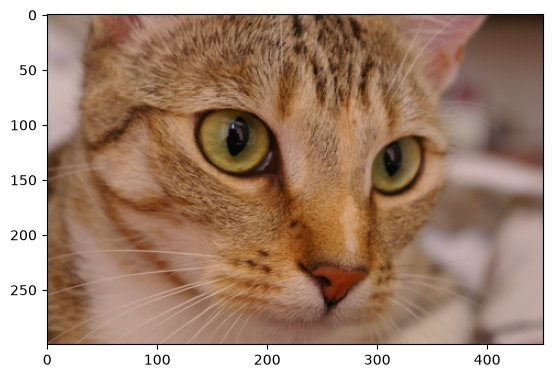

In [96]:
# source-cells: 92
plt.imshow(color_image);

In [97]:
# source-cells: 93

下面故意把 LAB 三通道直接交給 `imshow()`：它會把三個數當 RGB，因而顏色錯誤且可能被截斷。右側直方圖仍由未改動的 LAB 數值計算，紅、綠、藍線在此分別標示 L、a、b 通道，不是原圖的紅綠藍亮度。

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-24.971744792775286..78.02195800311549].


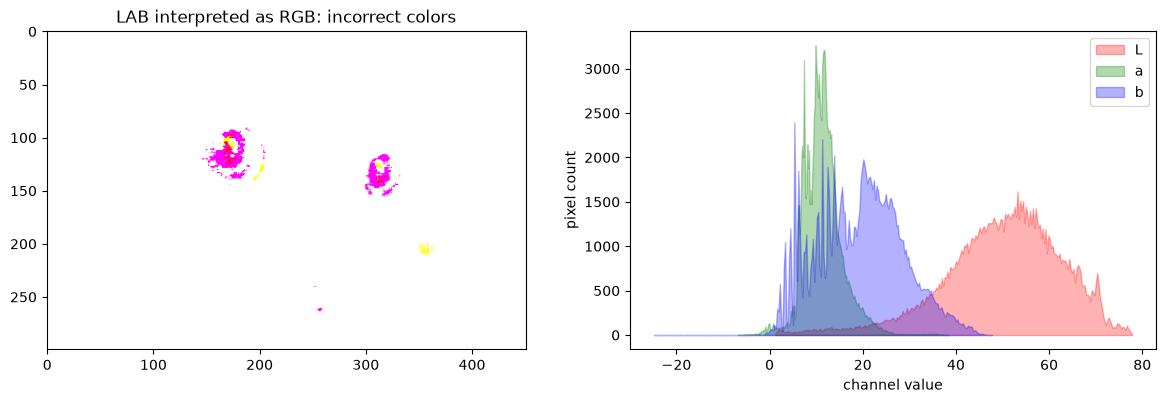

In [98]:
# source-cells: 94
imshow_with_histogram(lab_image);

In [99]:
# source-cells: 95

沿用原圖的閾值：`a < 0` 選眼睛附近，`a > 30` 選鼻子附近。兩個遮罩取聯集，再複製到三個通道，將其他像素設成黑色。這些條件依賴本圖顏色，換圖時需重新判斷。

In [100]:
# source-cells: 96
eyes = a < 0
nose = a > 30
mask = eyes|nose
mask =  np.expand_dims(mask, 2)
mask = np.repeat(mask, 3, axis=2)

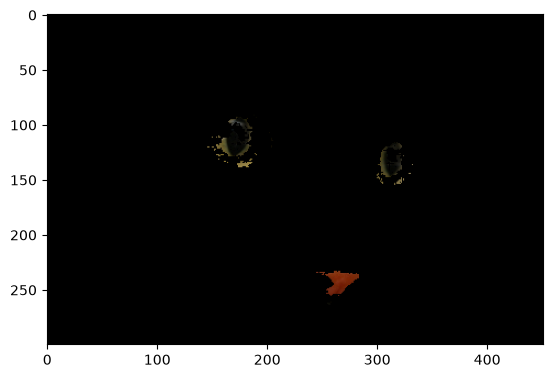

In [101]:
# source-cells: 97
plt.imshow(color_image*mask);

In [102]:
# source-cells: 98

### 影像反相

In [103]:
# source-cells: 99

`invert()` 對布林值交換 True／False，對無號整數以型別最大值減去原值，對一般浮點影像預設計算 `1-image`。有號整數與帶負值浮點另有各自慣例。下面反相前面修改過的灰階 Venusaur，觀察亮暗交換。

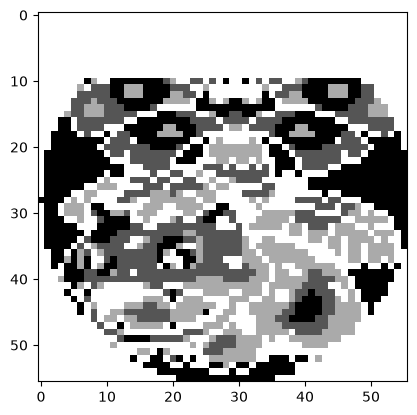

In [104]:
# source-cells: 100
inverted_img = ski.util.invert(venusaur)
plt.imshow(inverted_img, cmap='gray');

In [105]:
# source-cells: 101

## OpenCV 的 BGR 與 scikit-image 的 RGB

In [106]:
# source-cells: 102

OpenCV 的 `imread()` 預設讀成 `uint8` BGR 彩色影像，scikit-image 與 Matplotlib 則常使用 RGB。兩者都可以用 NumPy 存取；交換資料前，需要先確認通道順序。下面保留原 Blastoise 圖，先正確呈現 BGR 讀圖結果。

In [107]:
# source-cells: 103
# Matplotlib 直接顯示 NumPy 陣列，不切換讀圖 plugin。

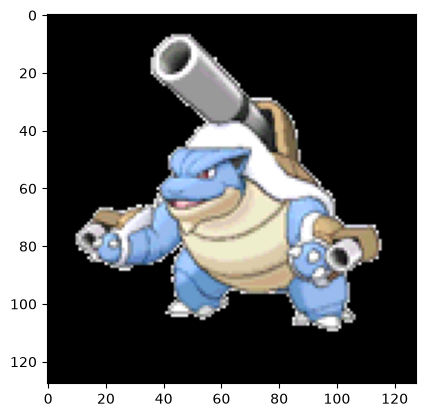

In [108]:
# source-cells: 104
blastoise = cv2.imread(str(image_path('blastoise.png')))
if blastoise is None:
    raise FileNotFoundError(image_path('blastoise.png'))
plt.imshow(cv2.cvtColor(blastoise, cv2.COLOR_BGR2RGB));

In [109]:
# source-cells: 105
blastoise.shape, blastoise.dtype

((128, 128, 3), dtype('uint8'))

In [110]:
# source-cells: 106

### BGR 與 RGB 的轉換

In [111]:
# source-cells: 107

彩色陣列依序是高、寬、通道。BGR 與 RGB 的差異在最後一軸，反轉通道不會交換列與欄。先把 BGR 直接當 RGB 顯示，看出錯色，再用 `image[:, :, ::-1]` 修正。

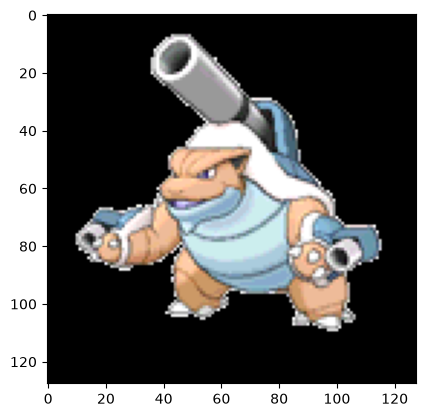

In [112]:
# source-cells: 108
plt.imshow(blastoise);

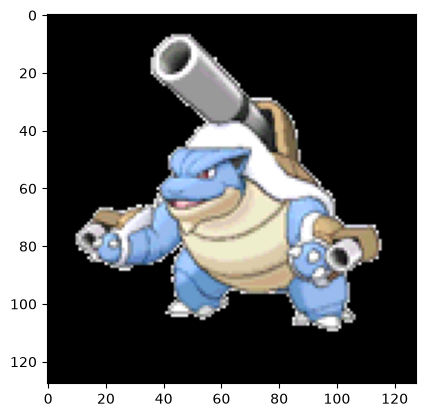

In [113]:
# source-cells: 109
blastoise = blastoise[:, :, ::-1]
plt.imshow(blastoise);

In [114]:
# source-cells: 110

### 兩套函式庫之間的型別轉換

In [115]:
# source-cells: 111

`uint8` RGB 陣列可以直接輸入多數 scikit-image 函式；需要浮點時使用 `ski.util.img_as_float()`。轉回 OpenCV 時，可用 `ski.util.img_as_ubyte()`，再視函式需要換回 BGR。通道順序與數值範圍要分開處理。

In [116]:
# source-cells: 112

## 用 Matplotlib 並排顯示影像

原教學延伸連結：[相關說明](https://scikit-image.org/docs/stable/user_guide/visualization.html)。可對照本節的定義與參數閱讀。

In [117]:
# source-cells: 113
charizardx = ski.io.imread(image_path('charizard-mega-x.png'))
charizardy = ski.io.imread(image_path('charizard-mega-y.png'))

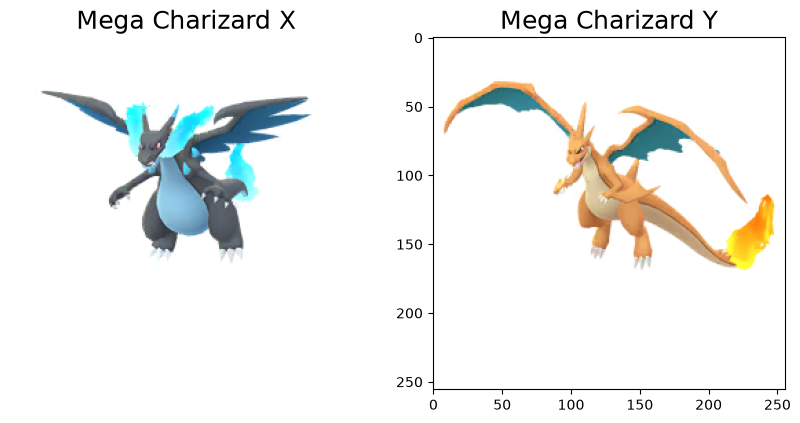

In [118]:
# source-cells: 114
f, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 5))
ax0.imshow(charizardx)
ax0.set_title('Mega Charizard X', fontsize=18)
ax0.axis('off')
ax1.imshow(charizardy)
ax1.set_title('Mega Charizard Y', fontsize=18);

In [119]:
# source-cells: 115

Matplotlib 對二維純量影像預設依最小、最大值正規化，再套用 colormap；RGB／RGBA 則依既定通道值顯示，不做同樣的逐圖伸展。上面兩張 Charizard 都是彩色圖。要公平比較灰階亮度，可指定相同的 `vmin`、`vmax`；[這則顯示比較](https://stackoverflow.com/questions/69140016/grayscale-image-different-in-cv2-imshow-and-matplotlib-pyplot-show)整理了 OpenCV 與 Matplotlib 的差異。

In [120]:
# source-cells: 116

## 對比與曝光調整

原教學延伸連結：[相關說明](https://scikit-image.org/docs/stable/api/skimage.exposure.html)。可對照本節的定義與參數閱讀。

In [121]:
# source-cells: 117

dtype 的可表示範圍和影像實際使用的範圍不同。例如 `uint8` 可存 0–255，一張低對比影像卻可能集中在很窄的區間。`ski.exposure` 提供非線性強度映射、範圍伸展與直方圖調整。

In [122]:
# source-cells: 118

Gamma 變換對每個像素使用相同的函數 $s=r^\gamma$。在 0–1 範圍內，$\gamma<1$ 抬高暗部，$\gamma>1$ 壓低暗部。`adjust_gamma()` 可實作這項變換；它不需要先計算整張圖的直方圖。

In [123]:
# source-cells: 119

另一類方法利用影像本身的直方圖。先看四個整數像素如何被分到 bins。

In [124]:
# source-cells: 120
image = np.array([[1, 3], [1, 1]])
ski.exposure.histogram(image)

(array([3, 0, 1]), array([1, 2, 3]))

In [125]:
# source-cells: 121

`ski.exposure.histogram()` 回傳像素計數與 bin 中心；`numpy.histogram()` 回傳計數與 bin 邊界。最簡單的對比伸展用 `rescale_intensity()` 將指定輸入區間線性映射到輸出範圍。

[Feature scaling](https://en.wikipedia.org/wiki/Feature_scaling) 比較不同的數值縮放方式；閱讀時對照本節的輸入與輸出範圍。

In [126]:
# source-cells: 122

### 重設強度範圍

In [127]:
# source-cells: 123

若暗背景中沒有真正亮點，把最低、最高值拉到全範圍，也會把背景雜訊放大成明顯亮斑。選擇伸展範圍時，需要知道數字原本代表什麼。

In [128]:
# source-cells: 124

相機可能只使用 10、12 或 14 位元，但用 `uint16` 儲存。已知是 10 位元資料時，輸入範圍是 0 到 $2^{10}-1$，可以明確指定：

```python
image = ski.exposure.rescale_intensity(img10bit, in_range=(0, 2**10 - 1))
```

In [129]:
# source-cells: 125

省略 `out_range` 時，輸出使用該 dtype 的慣例範圍。對 `uint16`，這會把已知 10 位元數值映射到 0–65535。

In [130]:
# source-cells: 126

有號整數轉成無號影像時，`img_as_ubyte()` 等工具會截斷負值。如果負值仍有資訊，應先指定要保留的輸入範圍，映射成非負數，再轉型。

In [131]:
# source-cells: 127

```python
# img_int32 是需要保留正負資訊的陣列
normalized = ski.exposure.rescale_intensity(
    img_int32.astype(float), in_range="image", out_range=(0.0, 1.0)
)
img_uint8 = ski.util.img_as_ubyte(normalized)
```

`out_range` 指定數值 tuple 時，輸出可能是浮點數。先映射到 0–1，才能符合後續 `img_as_ubyte()` 的輸入慣例。

In [132]:
# source-cells: 128

少數極端像素也會壓縮大多數像素的顯示對比。以下使用原 moon 圖的第 2、98 百分位數做伸展，另比較全域等化與 `clip_limit=0.03` 的局部等化。百分位區間外的像素會飽和，這部分資訊無法由輸出還原。

In [133]:
# source-cells: 129
# Load an example image
img = ski.data.moon()

# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = ski.exposure.rescale_intensity(img, in_range=(p2, p98))

# Equalization
img_eq = ski.exposure.equalize_hist(img)

# Adaptive Equalization
img_adapteq = ski.exposure.equalize_adapthist(img, clip_limit=0.03)

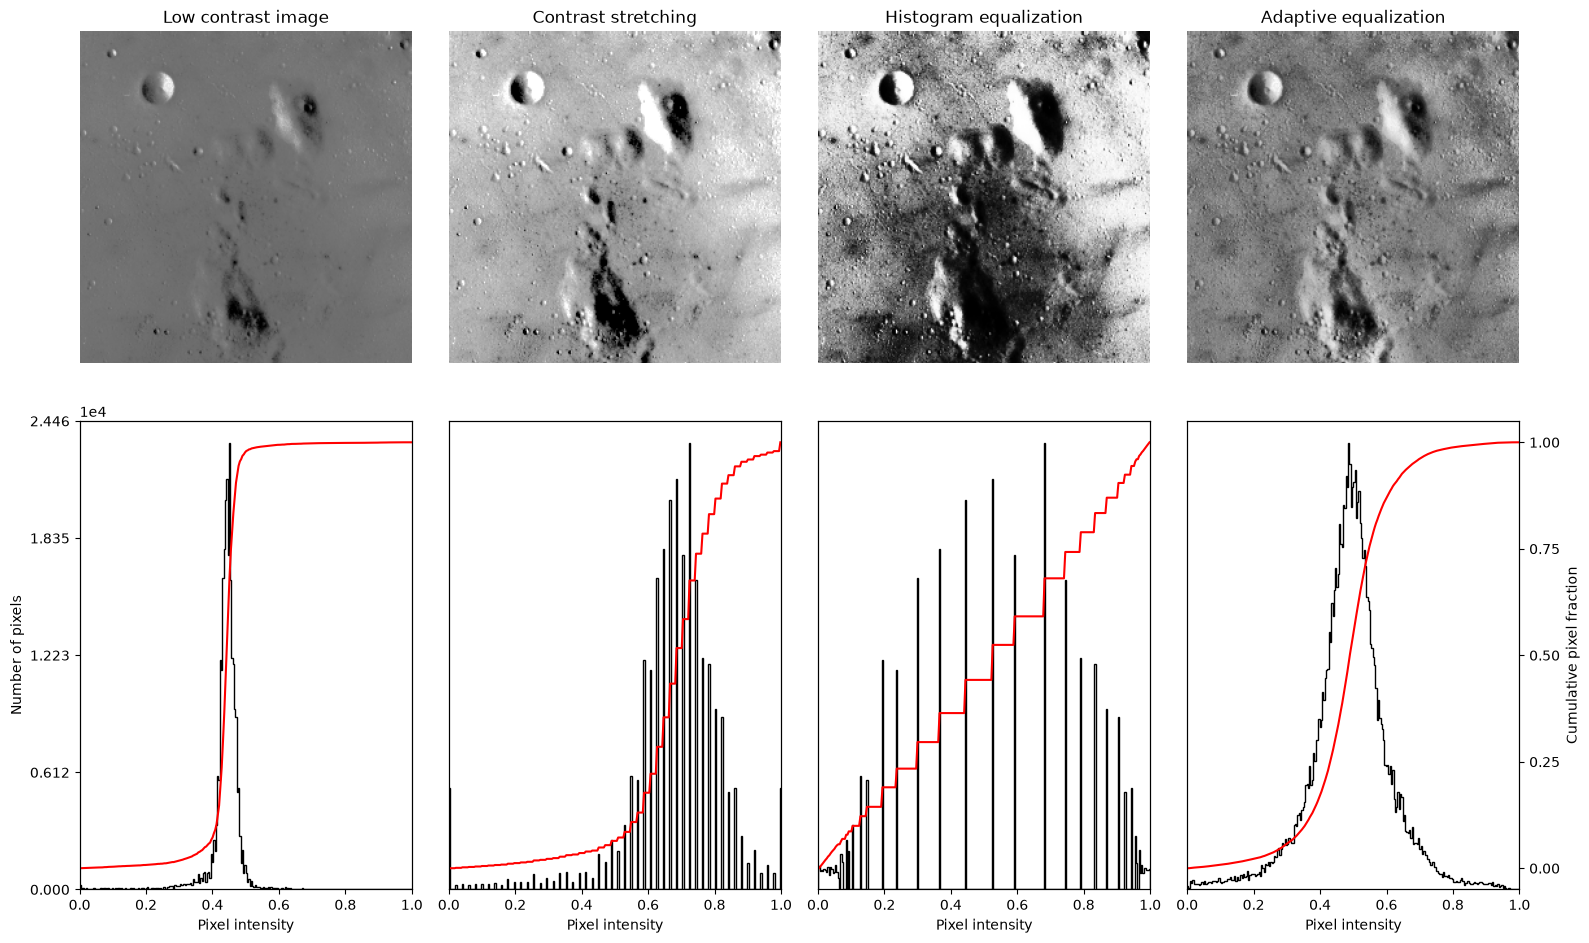

In [134]:
# source-cells: 130
# Display results
fig = plt.figure(figsize=(16, 10))
axes = np.zeros((2, 4), dtype=object)
axes[0, 0] = fig.add_subplot(2, 4, 1)
for i in range(1, 4):
    axes[0, i] = fig.add_subplot(2, 4, 1+i, sharex=axes[0,0], sharey=axes[0,0])
for i in range(0, 4):
    axes[1, i] = fig.add_subplot(2, 4, 5+i)

ax_img, ax_hist, ax_cdf = plot_img_and_hist(img, axes[:, 0])
ax_img.set_title('Low contrast image')
y_min, y_max = ax_hist.get_ylim()
ax_hist.set_ylabel('Number of pixels')
ax_hist.set_yticks(np.linspace(0, y_max, 5))
ax_img, ax_hist, ax_cdf = plot_img_and_hist(img_rescale, axes[:, 1])
ax_img.set_title('Contrast stretching')
ax_img, ax_hist, ax_cdf = plot_img_and_hist(img_eq, axes[:, 2])
ax_img.set_title('Histogram equalization')
ax_img, ax_hist, ax_cdf = plot_img_and_hist(img_adapteq, axes[:, 3])
ax_img.set_title('Adaptive equalization')
ax_cdf.set_ylabel('Cumulative pixel fraction')
ax_cdf.set_yticks(np.linspace(0, 1, 5));

# prevent overlap of y-axis labels
fig.tight_layout()

In [135]:
# source-cells: 131

直方圖等化利用累積分布函數映射強度，使輸出分布更接近均勻。離散影像有重複值與有限 bins，無法保證所有強度都出現一樣多次。局部等化則在不同區塊分別調整對比；CLAHE 的 clip limit 限制直方圖尖峰，降低局部雜訊過度放大的程度。圖中的紅線是累積像素比例，並非累積強度總量。

[直方圖等化](https://zh.wikipedia.org/wiki/%E7%9B%B4%E6%96%B9%E5%9B%BE%E5%9D%87%E8%A1%A1%E5%8C%96) 的圖例可對照本節的直方圖與累積像素比例。

In [136]:
# source-cells: 132

## 影像的幾何變換

原教學延伸連結：[相關說明](https://scikit-image.org/docs/stable/api/skimage.transform.html)。可對照本節的定義與參數閱讀。

In [137]:
# source-cells: 133

### 裁切、重縮放與調整尺寸

In [138]:
# source-cells: 134

裁切是陣列切片。下面從 Mega Charizard Y 左上角取出 $100\times100$ 區域，保留所有通道。新陣列的 `[0,0]` 對應原圖切片的起點。

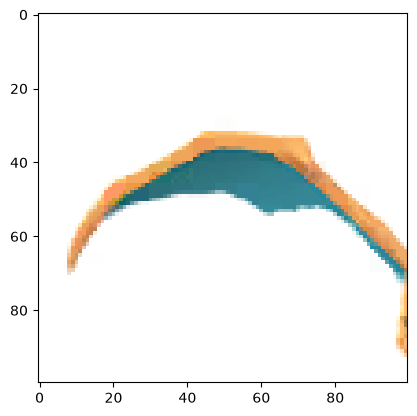

In [139]:
# source-cells: 135
img = charizardy
top_left = img[:100, :100]
plt.imshow(top_left);

In [140]:
# source-cells: 136

改變尺寸可指定比例、輸出 shape，或整數區塊。下面將 Mega Charizard X 與白背景混合後轉灰階，比較三種縮小方式。

In [141]:
# source-cells: 137

- `rescale()` 指定縮放比例；本例使用 0.5，故意關閉 anti-aliasing。
- `resize()` 指定輸出尺寸；本例每軸減半並開啟 anti-aliasing。
- `downscale_local_mean()` 使用區塊平均；本例每個 $2\times2$ 區塊變成一個值。
- `block_reduce()` 可改用平均或最大值等區塊運算。

(sampling)=

縮小會降低新網格的 Nyquist 頻率。先低通可減輕高頻折回的混疊；局部平均也有平滑作用，但不能保證完全消除混疊。

[Aliasing](https://en.wikipedia.org/wiki/Aliasing) 說明取樣後不同頻率如何變得無法區分，可對照這三種縮小方式。

In [142]:
# source-cells: 138
image = ski.color.rgb2gray(ski.color.rgba2rgb(charizardx))

image_rescaled = ski.transform.rescale(image, 0.5, anti_aliasing=False)
image_resized = ski.transform.resize(image, (image.shape[0] // 2, image.shape[1] // 2),
                       anti_aliasing=True)
image_downscaled = ski.transform.downscale_local_mean(image, (2, 2))

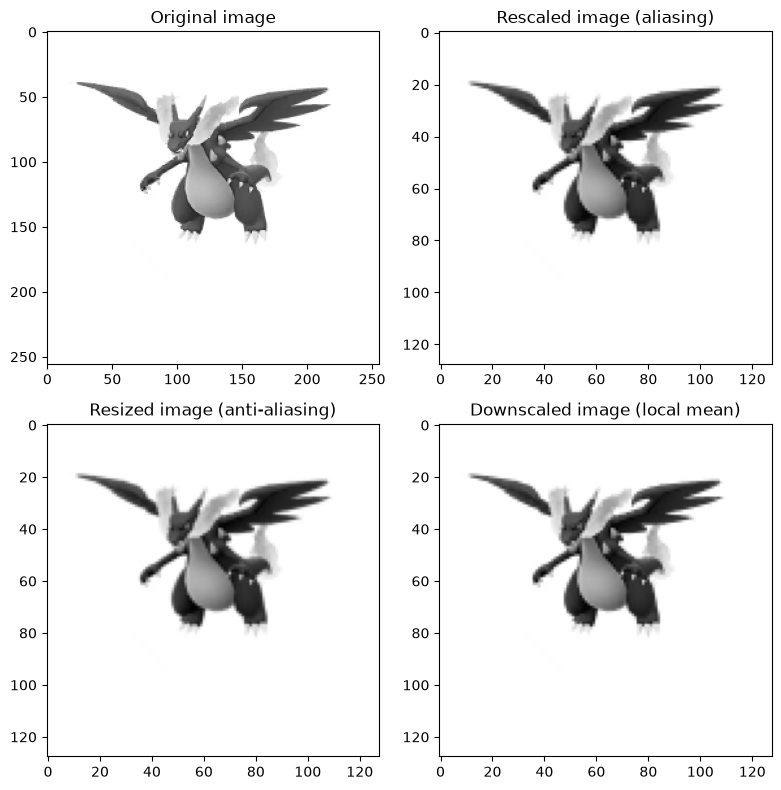

In [143]:
# source-cells: 139
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 8))

ax = axes.ravel()
#axes.ravel() 是一個將多維陣列展平成一維的操作，常用於處理 matplotlib 的子圖 (subplots) 布局。
ax[0].imshow(image, cmap='gray')
ax[0].set_title("Original image")

ax[1].imshow(image_rescaled, cmap='gray')
ax[1].set_title("Rescaled image (aliasing)")

ax[2].imshow(image_resized, cmap='gray')
ax[2].set_title("Resized image (anti-aliasing)")

ax[3].imshow(image_downscaled, cmap='gray')
ax[3].set_title("Downscaled image (local mean)")

plt.tight_layout()

In [144]:
# source-cells: 140

### 射影變換與齊次座標

In [145]:
# source-cells: 141

平面 homography 保留共線性，即同一直線上的點變換後仍共線。它包含限制更強的子類：仿射保留平行性，相似變換再保留形狀，剛體變換再保留距離。這些限制決定了模型能描述哪些變形。

原教學延伸連結：[相關說明](https://math.stackexchange.com/questions/1319680/what-is-the-difference-between-affine-and-projective-transformations)。可對照本節的定義與參數閱讀。

In [146]:
# source-cells: 142

以齊次座標 $(x,y,1)^{\mathsf T}$ 表示點，就能用 $3\times3$ 矩陣把平移和線性變換寫在一起。射影變換計算後還需除以第三分量。可以直接提供完整矩陣，也可以由旋轉、縮放、剪切與平移參數建立。

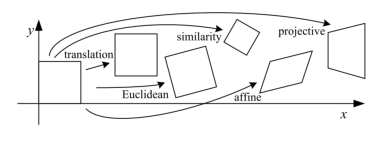

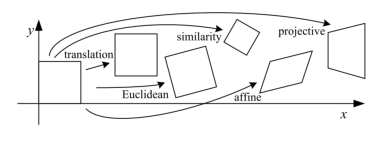

In [147]:
# source-cells: 143
# 原教學示意圖 1；來源：https://drive.google.com/uc?id=173_GZa3-rLcI6-8NIDqWBSbEAG-Reqat
show_images(ski.io.imread(image_path('ch01-cell143-1.png')))

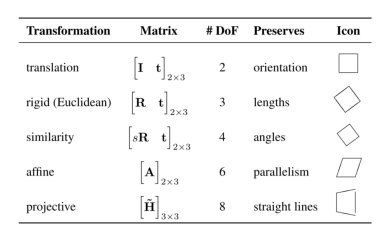

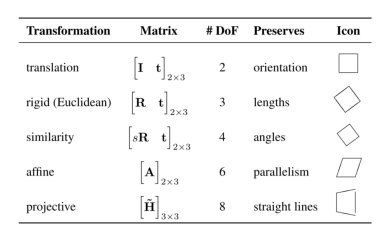

In [148]:
# source-cells: 143
# 原教學示意圖 2；來源：https://drive.google.com/uc?id=17409c95v1CWIF26JZyC30hIdur1YWLPL
show_images(ski.io.imread(image_path('ch01-cell143-2.png')))

In [149]:
diagram('geometry-family')

In [150]:
# source-cells: 144

### 歐幾里得（剛體）變換

In [151]:
# source-cells: 145

剛體變換保持距離。以下先繞原點旋轉 $15^\circ$，再平移 `(30,-20)`，並用手寫矩陣驗證兩種設定方式相同。影像座標的 x 向右、y 向下，因此這個正角在畫面上看來是順時針。

In [152]:
# source-cells: 146
tform = ski.transform.EuclideanTransform(
   rotation = np.pi / 12.,
   translation = (30, -20)
   )
tform.params

array([[  0.96592583,  -0.25881905,  30.        ],
       [  0.25881905,   0.96592583, -20.        ],
       [  0.        ,   0.        ,   1.        ]])

In [153]:
# source-cells: 147
matrix = np.array([[np.cos(np.pi/12), -np.sin(np.pi/12), 30],
          [np.sin(np.pi/12), np.cos(np.pi/12), -20],
          [0, 0, 1]])
tform = ski.transform.EuclideanTransform(matrix)
tform.params
assert np.allclose(matrix, ski.transform.EuclideanTransform(rotation=np.pi/12, translation=(30, -20)).params)

In [154]:
# source-cells: 148

`tform.params` 是齊次矩陣。矩陣相乘可組合變換，右邊的矩陣先作用。

`warp()` 對每個輸出像素回頭找輸入位置，需要 output→input 映射。上面的矩陣描述 input→output，所以傳入 `tform.inverse`。這是座標映射求逆，和像素反相不同；後面的四點校正會示範直接估計 output→input 的情形。

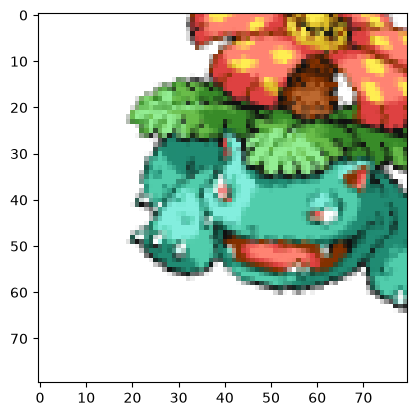

In [155]:
# source-cells: 149
img = ski.util.img_as_float(venusaurf)
tf_img = ski.transform.warp(img, tform.inverse)
plt.imshow(tf_img);

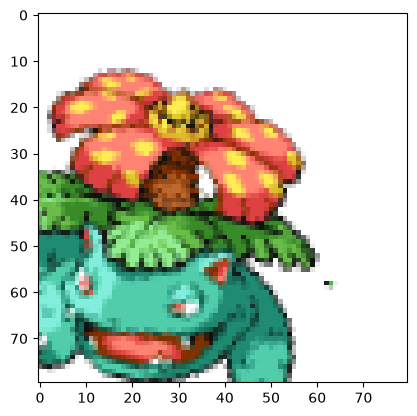

In [156]:
# source-cells: 150
tform = ski.transform.EuclideanTransform(
   rotation = np.pi / 12.,
   translation = (0, 0)
   )

img = ski.util.img_as_float(venusaurf)
tf_img = ski.transform.warp(img, tform.inverse)
plt.imshow(tf_img);

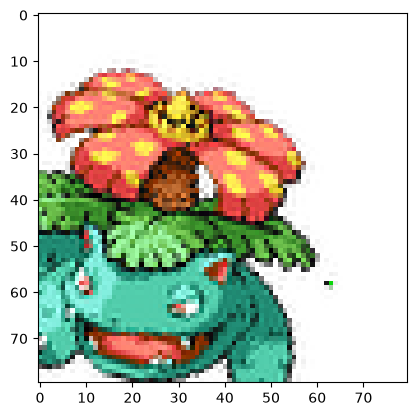

In [157]:
# source-cells: 151
tform = ski.transform.EuclideanTransform(
   rotation = np.pi / 12.,
   translation = (0, 0)
   )

img = ski.util.img_as_float(venusaurf)
tf_img = ski.transform.warp(img, tform.inverse, order=5) #interpolation
plt.imshow(tf_img);

### 內插階數與旋轉中心

剛才兩張圖都繞左上角原點順時針旋轉 $15^\circ$；`warp()` 對本例浮點影像預設採一階內插，`order=5` 使用五階內插。較高階可讓邊緣更平滑，也可能帶來過衝。

接著改用 `rotate()`，預設繞影像中心，正角在畫面上逆時針旋轉。`15` 度例子保留 0–255，故白背景用 `cval=255`；`-50` 度例子讓 uint8 轉成 0–1，白背景改用 `cval=1`。角度方向、中心與強度尺度都與前面的原點 warp 例子不同。

In [158]:
# source-cells: 152
venusaurf2.dtype

dtype('uint8')

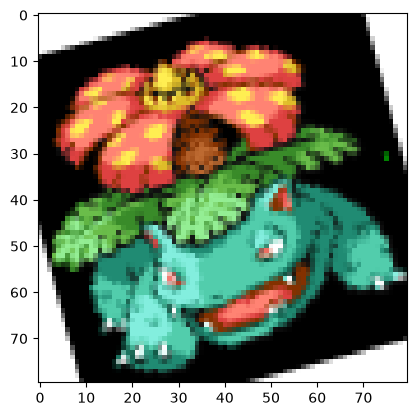

In [159]:
# source-cells: 153
img = ski.transform.rotate(venusaurf2, 15, mode='constant', cval=255, preserve_range=True) # Rotate image by a certain angle around its center.
plt.imshow(img.astype(np.uint8));

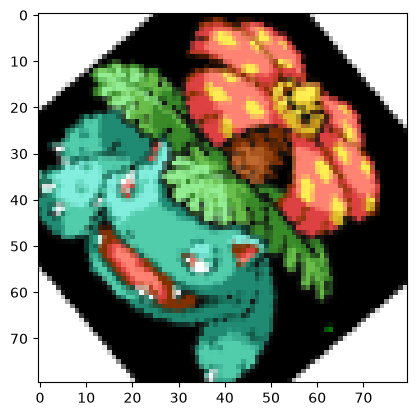

In [160]:
# source-cells: 154
img = ski.transform.rotate(venusaurf2, -50, mode='constant', cval=1) # Rotate image by a certain angle around its center. (output is float)
plt.imshow(img);

In [161]:
# source-cells: 155

### 相似變換

原教學延伸連結：[相關說明](https://en.wikipedia.org/wiki/Similarity_%28geometry%29)。可對照本節的定義與參數閱讀。

In [162]:
# source-cells: 156

相似變換保留角度與形狀，距離可乘上共同尺度。以下使用縮放 0.5、旋轉 $15^\circ$、平移 `(30,-20)`，和剛體例子並排理解縮放的作用。

[[  0.48296291  -0.12940952  30.        ]
 [  0.12940952   0.48296291 -20.        ]
 [  0.           0.           1.        ]]


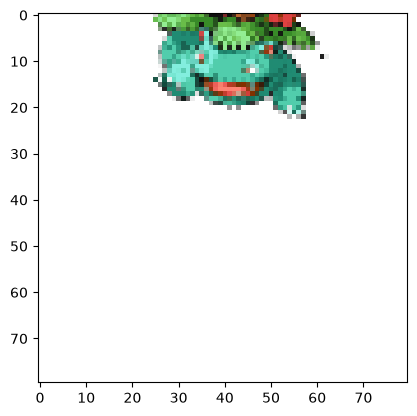

In [163]:
# source-cells: 157
tform = ski.transform.SimilarityTransform(
    scale=0.5,
    rotation=np.pi/12,
    translation=(30, -20))
print(tform.params)
tf_img = ski.transform.warp(venusaurf, tform.inverse)
plt.imshow(tf_img);

In [164]:
# source-cells: 158

### 仿射變換

In [165]:
# source-cells: 159

仿射變換保留直線與平行性，可組合旋轉、非等向縮放、剪切與平移。一般仿射變換包含比單一相似變換更多的自由度；以下單獨設定 `shear=pi/6`，觀察剪切如何改變形狀。

[剪切映射](https://en.wikipedia.org/wiki/Shear_mapping) 的幾何圖可對照下面的 pi/6 範例。

[[ 1.         -0.57735027  0.        ]
 [ 0.          1.          0.        ]
 [ 0.          0.          1.        ]]


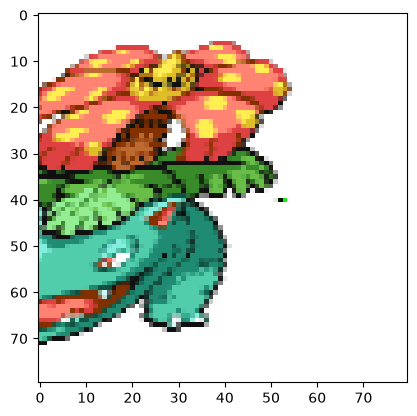

In [166]:
# source-cells: 160
tform = ski.transform.AffineTransform(
        shear=np.pi/6,
        )
print(tform.params)
tf_img = ski.transform.warp(venusaurf, tform.inverse)
plt.imshow(tf_img);

In [167]:
# source-cells: 161

### 一般射影變換

In [168]:
# source-cells: 162

一般射影變換保留直線，但平行線可相交。下面矩陣的最後一列含有非零的前兩項，除以新的齊次分量後，縮放就會隨位置改變。

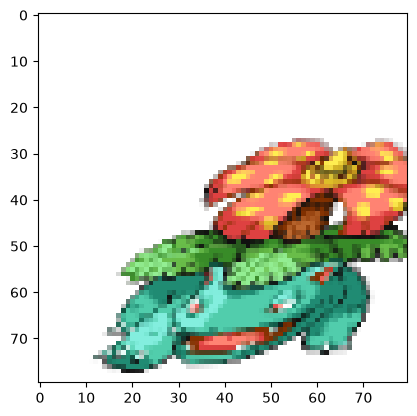

In [169]:
# source-cells: 163
matrix = np.array([[1, -0.5, 40],
          [0.1, 0.9, 20],
          [0.0015, 0.0015, 1]])
tform = ski.transform.ProjectiveTransform(matrix=matrix)
tf_img = ski.transform.warp(venusaurf, tform.inverse)
plt.imshow(tf_img);

In [170]:
# source-cells: 164

### 用對應點估計變換

In [171]:
# source-cells: 165

已知點對時，可估計把一組點映到另一組點的矩陣。平面文字從斜角拍攝會有透視變形；把文字區域校正成矩形後，比較字形會容易許多。

這個例子的 `src` 是輸出矩形座標，`dst` 是原始照片中的取樣位置。因此估得的 `tform3` 已是 output→input，可直接傳給 `warp(text, tform3)`，不需再求 inverse。輸出保留原設定 `(50,300)`。

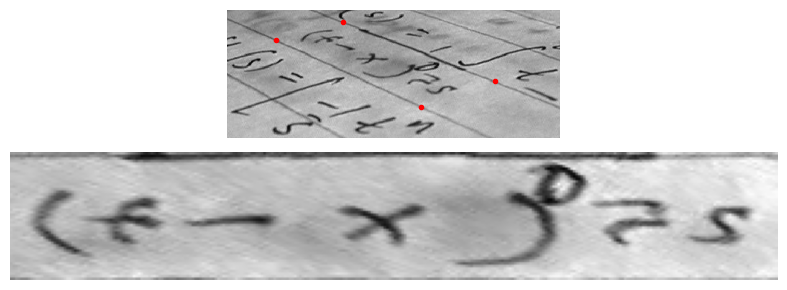

In [172]:
# source-cells: 166
text = ski.data.text()

src = np.array([[0, 0], [0, 50], [300, 50], [300, 0]])
dst = np.array([[155, 15], [65, 40], [260, 130], [360, 95]])

tform3 = ski.transform.ProjectiveTransform.from_estimate(src, dst)
if tform3 is None:
    raise ValueError('控制點無法估計有效 homography')
warped = ski.transform.warp(text, tform3, output_shape=(50, 300))

fig, ax = plt.subplots(nrows=2, figsize=(8, 3))

ax[0].imshow(text, cmap=plt.cm.gray)
ax[0].plot(dst[:, 0], dst[:, 1], '.r')
ax[1].imshow(warped, cmap=plt.cm.gray)

for a in ax:
    a.axis('off')

plt.tight_layout()
plt.show()

### 直接調整幾何參數

下方互動圖使用同一張修改後的 Venusaur 與文字照片。先選剛體、相似、剪切或射影範例，再改角度、平移與中心；對照上面的 Python 結果，確認影像如何取樣。


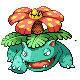
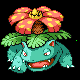
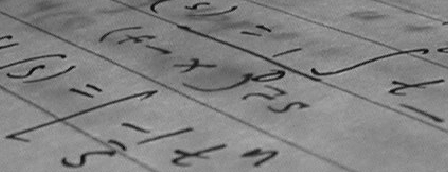

In [173]:
lab('geometry', image=venusaurf, rgb=venusaurf2, text_image=text)

In [174]:
# source-cells: 167

對應點選錯會把幾何校正拉向錯誤位置。已知點的可信度不同時，可在合適的估計方法中加入權重；若含有錯配，RANSAC 會反覆用少量點估模型，再看多少點支持它，降低離群點影響。[scikit-image 的 RANSAC 範例](https://scikit-image.org/docs/stable/auto_examples/transform/plot_matching.html#sphx-glr-auto-examples-transform-plot-matching-py)可接續閱讀。

In [175]:
# source-cells: 168

```{dropdown} 從文字校正延伸到鳥瞰圖
[BirdsEye](https://github.com/deepampatel/BirdsEye) 與 [social-distancing-monitoring](https://github.com/dongfang-steven-yang/social-distancing-monitoring) 展示將相機影像映射到地面視角的應用。閱讀時先找控制點與平面假設，再查看輸出座標如何換算距離。[Perspective Mappings](https://www.geometrictools.com/Documentation/PerspectiveMappings.pdf) 則用矩陣說明透視映射，適合對照本章最後一列非零的射影矩陣。
```

In [176]:
# source-cells: 169

## 延伸閱讀

In [177]:
# source-cells: 170

- **Szeliski, R.（2022），*Computer Vision: Algorithms and Applications*, 2nd ed.** [作者提供的書籍入口](https://szeliski.org/Book/)；閱讀第 2.1.1 節幾何變換、第 2.3 節數位相機，以及第 3.1 節點運算、第 3.5.1–3.5.2 節重縮放與金字塔、第 3.6 節幾何變換，對照本章像素、對比與校正例子 {cite}`szeliski2022`。
- **Forsyth, D. A. 與 Ponce, J.（2012），*Computer Vision: A Modern Approach*, 2nd ed.** 讀色彩、相機與幾何變換相關章節，補上色彩表示及透視成像的背景 {cite}`forsyth2012`。
- **Howse, J. 與 Minichino, J.（2020），*Learning OpenCV 4 Computer Vision with Python 3*, 3rd ed.** 對照影像基本處理、讀寫及通道操作，留意 BGR 與 RGB 的交換 {cite}`howse2020`。
- **OpenCV 官方教學**：[核心操作](https://docs.opencv.org/4.x/d7/d16/tutorial_py_table_of_contents_core.html)與[影像處理](https://docs.opencv.org/4.x/d2/d96/tutorial_py_table_of_contents_imgproc.html)，依本章的讀寫、色彩、幾何順序查參數。
- **scikit-image tutorials**：[原始範例](https://github.com/scikit-image/skimage-tutorials)，可從影像陣列與 transform 範例練習自行更換輸入圖。
- **Stanford CS131（2021）**：[公開課程](http://vision.stanford.edu/teaching/cs131_fall2021/)，接著讀影像形成、色彩與幾何的課程材料。